In [1]:
# data processing
import pandas as pd
import numpy as np
from collections import Counter
import imblearn
from pylab import *
%matplotlib inline
import rasterio
from classification_aux import inpsectiontocsv
import os

# modelling
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.inspection import permutation_importance
import joblib

In [2]:
filename = "prior_dataset_transformed.csv"
runname = "all_chicken_features"

In [3]:
runpath = os.path.join('runs', runname)
if not os.path.exists(runpath):
    os.mkdir(runpath)
df = pd.read_csv(filename)
df.head()

,site,veg_class,R,G,B,rc,gc,chm,bc,rc/gc,...,ExR,ExB,ExGmExR,Ikaw,MGRVI,GLI,Y,L,z_score_Y,z_score_L
0,CG1-8A,lichen,0.862745,0.847059,0.788235,0.345369,0.339089,1,0.315542,1.018519,...,0.360784,0.256471,-0.317647,0.045131,-0.018347,0.012896,0.685444,86.277954,0.901666,0.875787
1,CG1-8A,lichen,0.909804,0.901961,0.850980,0.341679,0.338733,1,0.319588,1.008696,...,0.371765,0.289412,-0.328627,0.033408,-0.008658,0.012101,0.787592,91.125221,1.338999,1.162117
2,CG1-8A,lichen,0.894118,0.886275,0.839216,0.341317,0.338323,1,0.320359,1.008850,...,0.365490,0.288627,-0.326275,0.031674,-0.008810,0.011186,0.757417,89.739293,1.209810,1.080249
3,CG1-8A,lichen,0.909804,0.901961,0.858824,0.340675,0.337739,1,0.321586,1.008696,...,0.371765,0.300392,-0.336471,0.028825,-0.008658,0.009879,0.788639,91.172679,1.343483,1.164920
4,CG1-8A,lichen,0.937255,0.937255,0.850980,0.343885,0.343885,1,0.312230,1.000000,...,0.374902,0.254118,-0.288627,0.048246,0.000000,0.023555,0.850935,93.923383,1.610195,1.327405


In [4]:
def split_by_site(df, site):
    site_indices = df['site'] == site

    selection = list(df.columns)
    selection.remove('site')
    selection.remove('veg_class')

    X = df[selection]
    y = df['veg_class']
    X_train = X[~site_indices]
    X_test = X[site_indices]
    y_train = y[~site_indices]
    y_test = y[site_indices]

    return X_train, X_test, y_train, y_test

In [13]:
a = list(df['site'].unique())
shuffle(a)
a

['F3-19B',
 'CG1-8A',
 'ZF46-37A',
 'CS117B',
 'CS-103B',
 'CS-59B',
 'CS3B',
 'F3-8B',
 'CG1-8B',
 'CS-46A',
 'F3-20A',
 'CS-46B',
 'F3-20B',
 'F3-8A',
 'F3-8C',
 'ZF20-11A',
 'CS-96B',
 'ZF46-15A',
 'F3-19C',
 'F3-20C']

In [14]:
for site in a[:6]:
    print(f'Holding out site {site}...')
    X_train, X_test, y_train, y_test = split_by_site(df, site)
    

    # -----------------------------------------------------------------------------------------------------------
    # oversample w synthetic minority oversampling to balance classes
    under = imblearn.over_sampling.SMOTE(sampling_strategy='not majority') # resamples all classes but majority
    X_res, y_res = under.fit_resample(X_train, y_train)
    
    # -----------------------------------------------------------------------------------------------------------
    # Train RF classifier
    clf=RandomForestClassifier(n_estimators=500, max_depth=15)
    clf.fit(X_res, y_res)
    
    # -----------------------------------------------------------------------------------------------------------
    # Prediction
    preds = clf.predict(X_test)
    
    print(f'  Train accuracy: {clf.score(X_res, y_res)}')
    print(f'  Test accuracy: {clf.score(X_test, y_test)}')

Holding out site F3-19B...
  Train accuracy: 0.9294731610337972
  Test accuracy: 0.7076788830715532
Holding out site CG1-8A...
  Train accuracy: 0.9280628608082104
  Test accuracy: 0.6594594594594595
Holding out site ZF46-37A...
  Train accuracy: 0.9350993377483444
  Test accuracy: 0.3693467336683417
Holding out site CS117B...
  Train accuracy: 0.9296302549383758
  Test accuracy: 0.6640070921985816
Holding out site CS-103B...
  Train accuracy: 0.932027027027027
  Test accuracy: 0.6652360515021459
Holding out site CS-59B...
  Train accuracy: 0.9304411287706779
  Test accuracy: 0.5834031852472757


In [15]:
df = pd.read_csv('dataset_file_transformed.csv')
for site in a[:6]:
    print(f'Holding out site {site}...')
    X_train, X_test, y_train, y_test = split_by_site(df, site)
    

    # -----------------------------------------------------------------------------------------------------------
    # oversample w synthetic minority oversampling to balance classes
    under = imblearn.over_sampling.SMOTE(sampling_strategy='not majority') # resamples all classes but majority
    X_res, y_res = under.fit_resample(X_train, y_train)
    
    # -----------------------------------------------------------------------------------------------------------
    # Train RF classifier
    clf=RandomForestClassifier(n_estimators=500, max_depth=15)
    clf.fit(X_res, y_res)
    
    # -----------------------------------------------------------------------------------------------------------
    # Prediction
    preds = clf.predict(X_test)
    
    print(f'  Train accuracy: {clf.score(X_res, y_res)}')
    print(f'  Test accuracy: {clf.score(X_test, y_test)}')

Holding out site F3-19B...
  Train accuracy: 0.98710825236075
  Test accuracy: 0.56282722513089
Holding out site CG1-8A...
  Train accuracy: 0.9876781670440922
  Test accuracy: 0.5216216216216216
Holding out site ZF46-37A...
  Train accuracy: 0.98744253251018
  Test accuracy: 0.35510887772194305
Holding out site CS117B...
  Train accuracy: 0.9888101195440645
  Test accuracy: 0.4875886524822695
Holding out site CS-103B...
  Train accuracy: 0.9875399805312196
  Test accuracy: 0.6781115879828327
Holding out site CS-59B...
  Train accuracy: 0.9872932634126664
  Test accuracy: 0.5582564962279967


In [ ]:
# -----------------------------------------------------------------------------------------------------------
# Inspect performance parameters: training and testing scores, confusion matrix, and feature importanceax1 = plt.figure(figsize=(5,5)).add_subplot(111)

cf_matrix = confusion_matrix(y_test, preds,  labels = clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cf_matrix, display_labels=clf.classes_)
disp.plot(ax = ax1)
plt.title('Confusion Matrix')

feature_importance = pd.DataFrame(clf.feature_importances_, index=X_res.columns).sort_values(by=0, ascending=False)
print(feature_importance)

# -----------------------------------------------------------------------------------------------------------
# save inspection results to csv output file and confusion matrix to figure
savepath = os.path.join('runs', runname)
savename = f'{runname}.csv'
inpsectiontocsv(savepath=savepath, savename=savename, selection=selection, clf=clf, cf_matrix=cf_matrix, 
                training_data=[X_res, y_res], testing_data=[X_test, y_test])

figname=f'cfm_{runname}.png'
savefig(savepath+figname, dpi=150, bbox_inches='tight')

[  0 275 274 273 272 271 270 269 268 267 266 265 264 263 262 261 260 259
 258 257 256 255 276 254 277 279 300 299 298 297 296 295 294 293 292 291
 290 289 288 287 286 285 284 283 282 281 280 278 253 252 251 224 223 222
 221 220 219 218 217 216 215 214 213 212 211 210 209 208 207 206 205 204
 225 226 227 228 250 249 248 247 246 245 244 243 242 241 301 240 238 237
 236 235 234 233 232 231 230 229 239 203 302 304 376 375 374 373 372 371
 370 369 368 367 366 365 364 363 362 361 360 359 358 357 356 377 355 378
 380 401 400 399 398 397 396 395 394 393 392 391 390 389 388 387 386 385
 384 383 382 381 379 354 353 352 325 324 323 322 321 320 319 318 317 316
 315 314 313 312 311 310 309 308 307 306 305 326 327 328 329 351 350 349
 348 347 346 345 344 343 342 303 341 339 338 337 336 335 334 333 332 331
 330 340 202 201 200  72  71  70  69  68  67  66  65  64  63  62  61  60
  59  58  57  56  55  54  53  52  73  51  74  76  97  96  95  94  93  92
  91  90  89  88  87  86  85  84  83  82  81  80  7

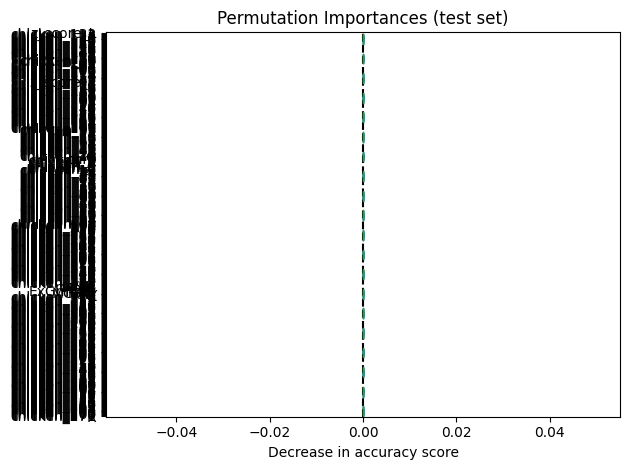

In [21]:
# ==========================================================================================
# Calculate permutation matrix and save figure
# ==========================================================================================
perm_importance = permutation_importance(clf, X_test, y_test)
sorted_idx = perm_importance.importances_mean.argsort()
print(sorted_idx)
importances = pd.DataFrame(
    perm_importance.importances[sorted_idx].T,
    columns=X.columns[sorted_idx],
)

ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()
figname = f'perm_{runname}.png'
savefig(savepath+figname, dpi=150, bbox_inches='tight')

In [6]:
# ==========================================================================================
# save classifier in object 
# ==========================================================================================

# Add columns attribute to classifier. 
# This is important information as .tifs that should be classified need to have the same features and in the same order
clf.col_names=X.columns

# -----------------------------------------------------------------------------------------------------------
# !! careful this can make objects of several GB size
outpath = 'data/clfs/'
outfile = 'clf_%s_TEST.pkl' % run
joblib.dump(clf, outpath+outfile) 

['data/clfs/clf_run6_orthotest_500-15_TEST.pkl']